In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(8)') 

array([2, 3, 4, 5, 6, 7, 8, 9])

In [13]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles
        using CSV
        using DataFrames 
            
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
        
        df_splitting_moments = CSV.read("NP splitting grid/splitting_moments_grid.csv", DataFrame)
        df_hard_moments = CSV.read("NP hard grid/hard_moments_grid.csv", DataFrame)     

    end
""")

Main.include("core\\setting.jl")
Main.include("core\\constants.jl")
Main.include("core\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\FO.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("initialization.jl")
Main.include("Σb qg.jl")
Main.include("cross section qg.jl")
Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

In [4]:
error_type = "both"

df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

Data Selection

In [5]:
#-------------------------------------------------------------------
dataset_names = ["OPAL_new","SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------
#dataset_names = ["SLD","TOPAZ_595","TOPAZ_533",
#                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------
#dataset_names = ["MAC"]

df = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df0 = pd.read_csv(file_path)
    
    χ = df0["CHI"]
    EEC = df0["EEC"]
    ERROR = df0["ERROR"]
    Q = df0["Q"]
    BinSize = df0["BinSize"]

    print(Q[0])

    if error_type == "both":
        
        Main.αs_Z = 0.118
        αs = Main.alpha_s_func(Q[0])
        a = αs/(2*np.pi)

        fixed_error=[]
        for angle in χ:
            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
            fixed_error.append(value)
        ERROR = np.sqrt(df0["ERROR"]**2 + np.array(fixed_error)**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q, "BinSize": BinSize})
    df[name] = df1

91.2
91.2
59.5
53.3
43.5
34.8
29.0
29.0


Kinematic Cut

In [7]:
cut_list = {}
#cut_list["sqrtz"] = [0,1/2]
#cut_list["χ"] = [0,90]
cut_list["χ"] = [0,90]
#cut_list["kt"] = []

In [8]:
df_truncated = {}

χ = {}
EEC = {}
ERROR = {}
Q = {}
BinSize = {}

for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*df[name]["Q"]

    if "sqrtz" in cut_list:
        sqrtz_lower, sqrtz_upper = cut_list["sqrtz"]
        df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

    if "kt" in cut_list:
        kt_lower, kt_upper = cut_list["kt"]
        df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

    if "χ" in cut_list:
        χ_lower, χ_upper = cut_list["χ"]
        df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    Q[name] = np.array(df_truncated[name]["Q"])
    BinSize[name] = np.array(df_truncated[name]["BinSize"])

#display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

89

24

24

24

24

24

24

24

Chi-Square calculation

In [9]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

import sys
def objective(params, df):

    N = 5
    
    chi2 = 0
    N_total = 0
    
    αs = params[0]
    params_noαs = np.asarray(params[1:], dtype=float)

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 

    dataset_names = df.keys()
    chi_square = {}
    for name in dataset_names:
        xlist={}
        xlist_mid = np.array(df[name]["CHI"])
        binsize = np.array(df[name]["BinSize"]) 
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        data_size = len(xlist_mid)
        N_total = N_total + data_size

        PRED={}

        parameters = params_noαs

        for quartile in range(N):
            PRED[quartile] = Main.model(xlist=xlist[quartile], Qlist=np.array(df[name]["Q"]))                
        DELTA =  DELTA_func(ylist,PRED)                       

        chi_square[name] = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square[name]

    #display(chi_square)
    return chi2/N_total

In [10]:
import csv
import sys

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin
    
if_renormalon = False

In [11]:
df_ansatzes = pd.DataFrame([
    {"ansatz": (
            "exp(-a[2]*b^a[3])",      # NP_quark
            "exp(-a[5]*b^a[3])"       # NP_gluon
        ),
     "params": [0.118, 0.89, 2.45, 1.13, 1.1]
	},             
])

In [14]:
for nth in range(len(df_ansatzes)):
    chi2 = objective(df_ansatzes["params"].iloc[nth], df_truncated)
    print(chi2)

4.594707906564912


In [57]:
a1 = 2.45
a2 = 1.13

for b in np.linspace(0.0001,5,1000):
    Main.init_splitting_globals(b=b, a1=a1, a2=a2)
    Main.init_hard_globals(b=b, a1=a1, a2=a2)

In [59]:
a1 = 2.45
a2 = 1.13

b0 = 1.122918967

for b in np.linspace(0.0001,5,1000):
    Main.init_splitting_globals(b=b, a1=a1, a2=a2)
    Main.init_hard_globals(b=b, a1=a1, a2=a2)

    bstar = b/np.sqrt(1+b**2/b0**2)
    Lb = np.log((91.2/(b0/bstar))**2)
    a=Main.Σb_quark_func(Lb=Lb, a_s=0.118/(4*np.pi), order=2, nf=5)
    b=Main.Σb_gluon_func(Lb=Lb, a_s=0.118/(4*np.pi), order=2, nf=5)

In [91]:
def round_sig(x, sig=3):
    if isinstance(x, np.ndarray):
        return np.array([round_sig(val, sig) for val in x])
    elif isinstance(x, list):
        return [round_sig(val, sig) for val in x]
    elif x == 0:
        return 0
    else:
        return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

Local then hopping

In [92]:
sqrtz_upper_list = []
#sqrtz_upper_list = []
kt_upper_list = []
#kt_upper_list = []
χ_upper_list = list(range(50, 91, 5))
#χ_lower_list = []

In [93]:
from itertools import product

cut_list = []
for sqrtz_upper, kt_upper, χ_upper in product(
        sqrtz_upper_list or [None],
        kt_upper_list    or [None],
        χ_upper_list     or [None],        
):
    cuts = {}
    if sqrtz_upper is not None:
        cuts["sqrtz"] = [0, round_sig(sqrtz_upper)]
    if kt_upper    is not None:
        cuts["kt"]    = [0, round_sig(kt_upper)]
    if χ_upper     is not None:
        cuts["χ"]     = [0, round_sig(χ_upper)]        
    cut_list.append(cuts)
cut_list

[{'χ': [0, 50]},
 {'χ': [0, 55]},
 {'χ': [0, 60]},
 {'χ': [0, 65]},
 {'χ': [0, 70]},
 {'χ': [0, 75]},
 {'χ': [0, 80]},
 {'χ': [0, 85]},
 {'χ': [0, 90]}]

In [94]:
result_df = pd.DataFrame(columns=["N", "ansatz", "cut", "αs", "params", "χ2/N"])

for nth in range(len(df_ansatzes)):
    for cuts in tqdm(cut_list):
        set_NP(df_ansatzes["ansatz"].iloc[nth])

        df_truncated = {}
        χ = {}
        EEC = {}
        ERROR = {}

        N_total = 0
        for name in dataset_names:
            sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
            kt_list = sqrtz_list*df[name]["Q"]

            if "sqrtz" in cuts:
                sqrtz_lower, sqrtz_upper = cuts["sqrtz"]
                df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

            if "kt" in cuts:
                kt_lower, kt_upper = cuts["kt"]
                df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

            if "χ" in cuts:
                χ_lower, χ_upper = cuts["χ"]
                df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
            
            N_total = N_total + len(df_truncated[name]["CHI"])

        initial_params = df_ansatzes["params"].iloc[nth]

        bounds = []
        bounds.append([0.118,0.118])
        bounds.append([0.8,1.2])
        bounds.append([2.0,4.0])                                                                               
        bounds.append([0.5,1.5])
        bounds.append([0.5,1.5])
        bounds.append([2.0,10.0])

        bounds_T = [list(t) for t in zip(*bounds)]

        minimizer_kwargs = {
            "method": "L-BFGS-B",
            "bounds": bounds,
            "args": (df_truncated),
            "options": {'maxiter': 100, 'disp': True, "ftol": 10**(-9)},
        }

        result = basinhopping(
            objective,
            initial_params,
            minimizer_kwargs=minimizer_kwargs,
            niter=0,
            accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
        )

        optimal = result.x
        optimal_αs = optimal[0]
        optimal_params = optimal[1:]                        
        result_df.loc[len(result_df)] = [N_total, df_ansatzes["ansatz"].iloc[nth], cuts, 
                                         round_sig(optimal_αs,4), round_sig(optimal_params,4), round_sig(result.fun)]

result_df.to_csv("result.csv", index=False)
display(result_df)

100%|██████████| 9/9 [12:15<00:00, 81.70s/it]


,N,ansatz,cut,αs,params,χ2/N
0,91,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 50]}",0.118,"[0.8363, 2.784, 1.161, 1.338, 8.13]",1.30
1,98,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 55]}",0.118,"[0.8369, 2.783, 1.161, 1.325, 8.093]",1.25
2,112,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 60]}",0.118,"[0.8336, 2.786, 1.165, 1.384, 8.348]",1.21
3,119,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 65]}",0.118,"[0.8344, 2.786, 1.163, 1.369, 8.43]",1.16
4,126,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 70]}",0.118,"[0.8343, 2.788, 1.164, 1.371, 8.336]",1.14
5,140,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 75]}",0.118,"[0.838, 2.789, 1.16, 1.325, 7.876]",1.11
6,147,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 80]}",0.118,"[0.837, 2.794, 1.163, 1.338, 7.633]",1.11
7,161,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 85]}",0.118,"[0.8396, 2.803, 1.166, 1.311, 6.185]",1.18
8,168,"(exp(-a[2]*b^a[3]), exp(-a[5]*b^a[3]))","{'χ': [0, 90]}",0.118,"[0.8407, 2.804, 1.167, 1.301, 5.584]",1.21


In [20]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x000001f61fc0a8c0>

Plot

In [21]:
χ_low = 0.1
χ_up = 60.0
kt_lower = 0
kt_upper = 100
sqrtz_cut = 1/2
optimal_params= [0.118, 0.876, 2.71, 1.11, 1.14]

In [22]:
Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["OPAL_new"]  = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0
Q_list["TASSO_220"] = 22.0
Q_list["TASSO_140"] = 14.0

In [23]:
N_points = 200

xlist = np.linspace(χ_low, χ_up, N_points, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    Qlist = Q_list[name]*np.ones(N_points)

    parameters = params_noαs

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 
    
    if len(parameters) > 0:
        v[name] = Main.model(Qlist=Qlist, xlist=xlist)
    else:
        v[name] = Main.model(Qlist=Qlist, xlist=xlist)      

[0.876, 2.71, 1.11, 1.14]


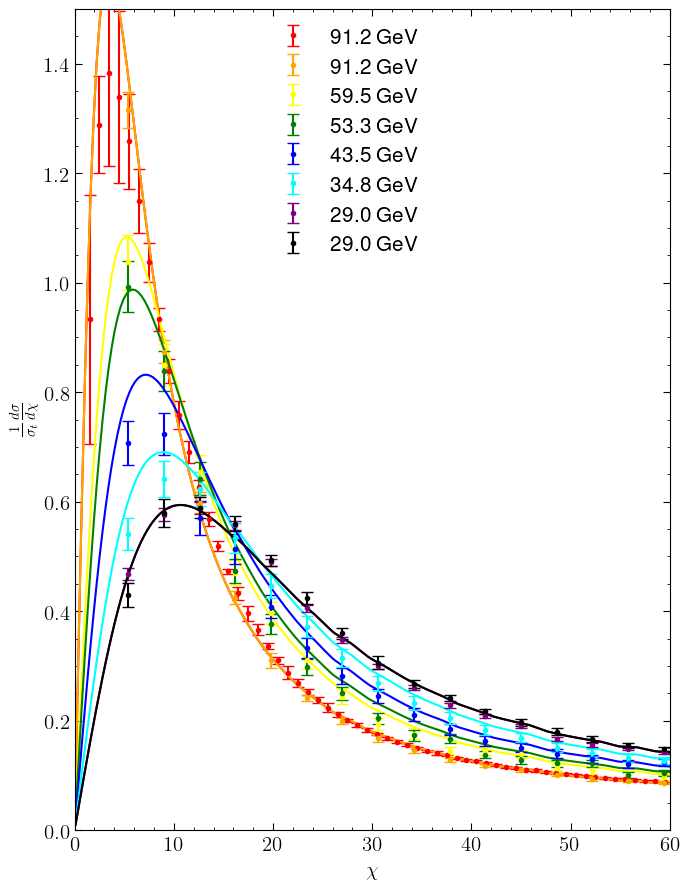

In [24]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black","yellow","orange"]
i=0
for name in dataset_names:
    ax1.errorbar(df_truncated[name]["CHI"], df_truncated[name]["EEC"], df_truncated[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist, v[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.3, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.0,1.5)
plt.xlim(0.0,χ_up)

plt.tight_layout()  
plt.show()

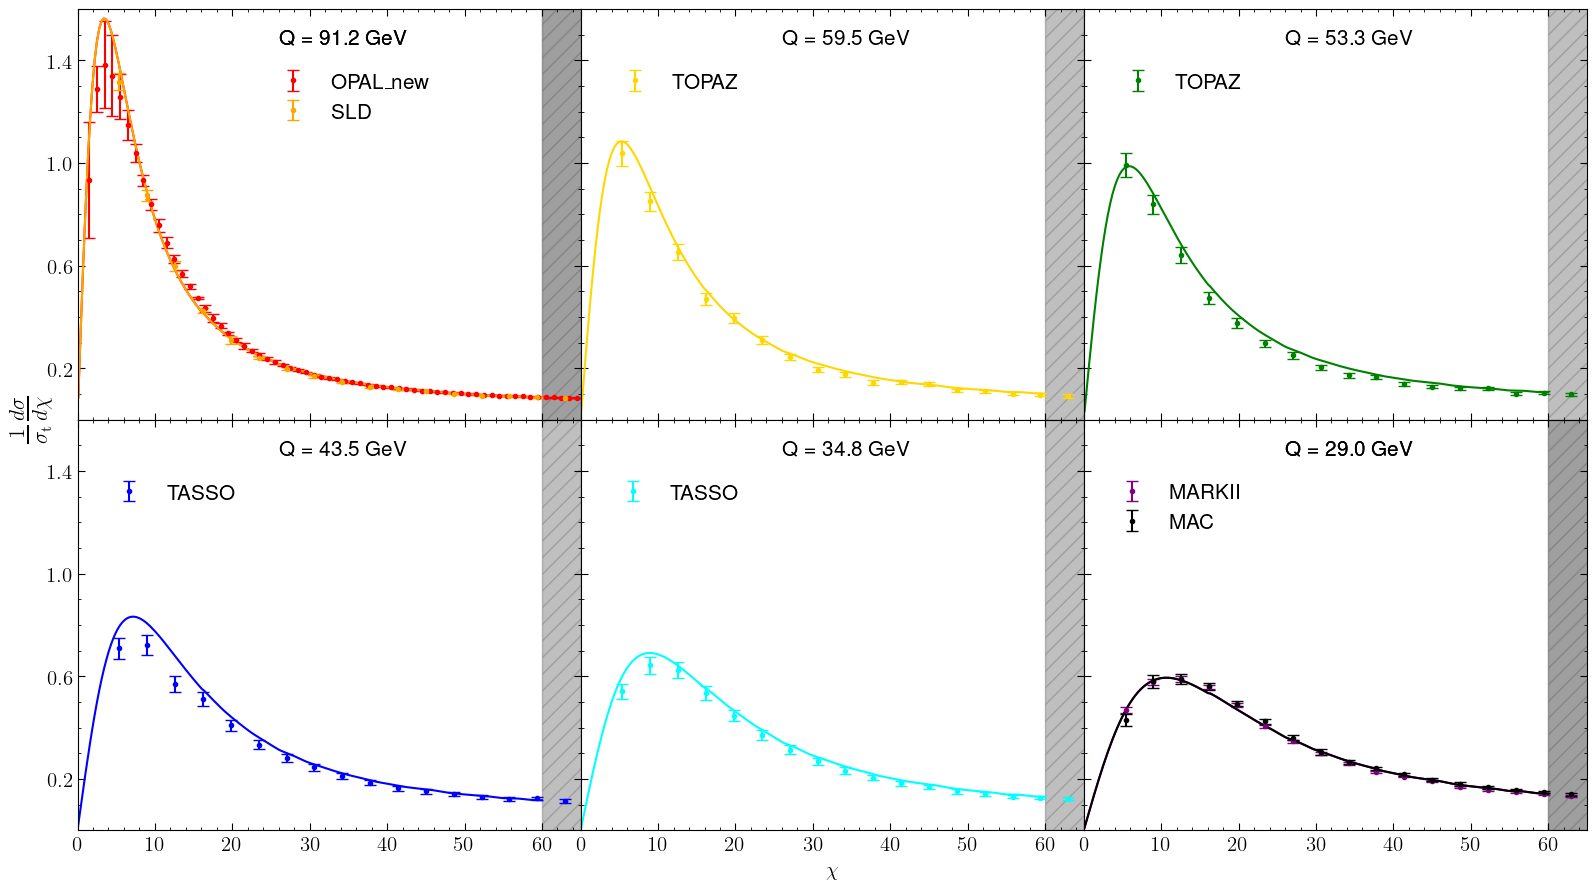

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(xlist, v[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
            χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
            #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
            ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,65)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

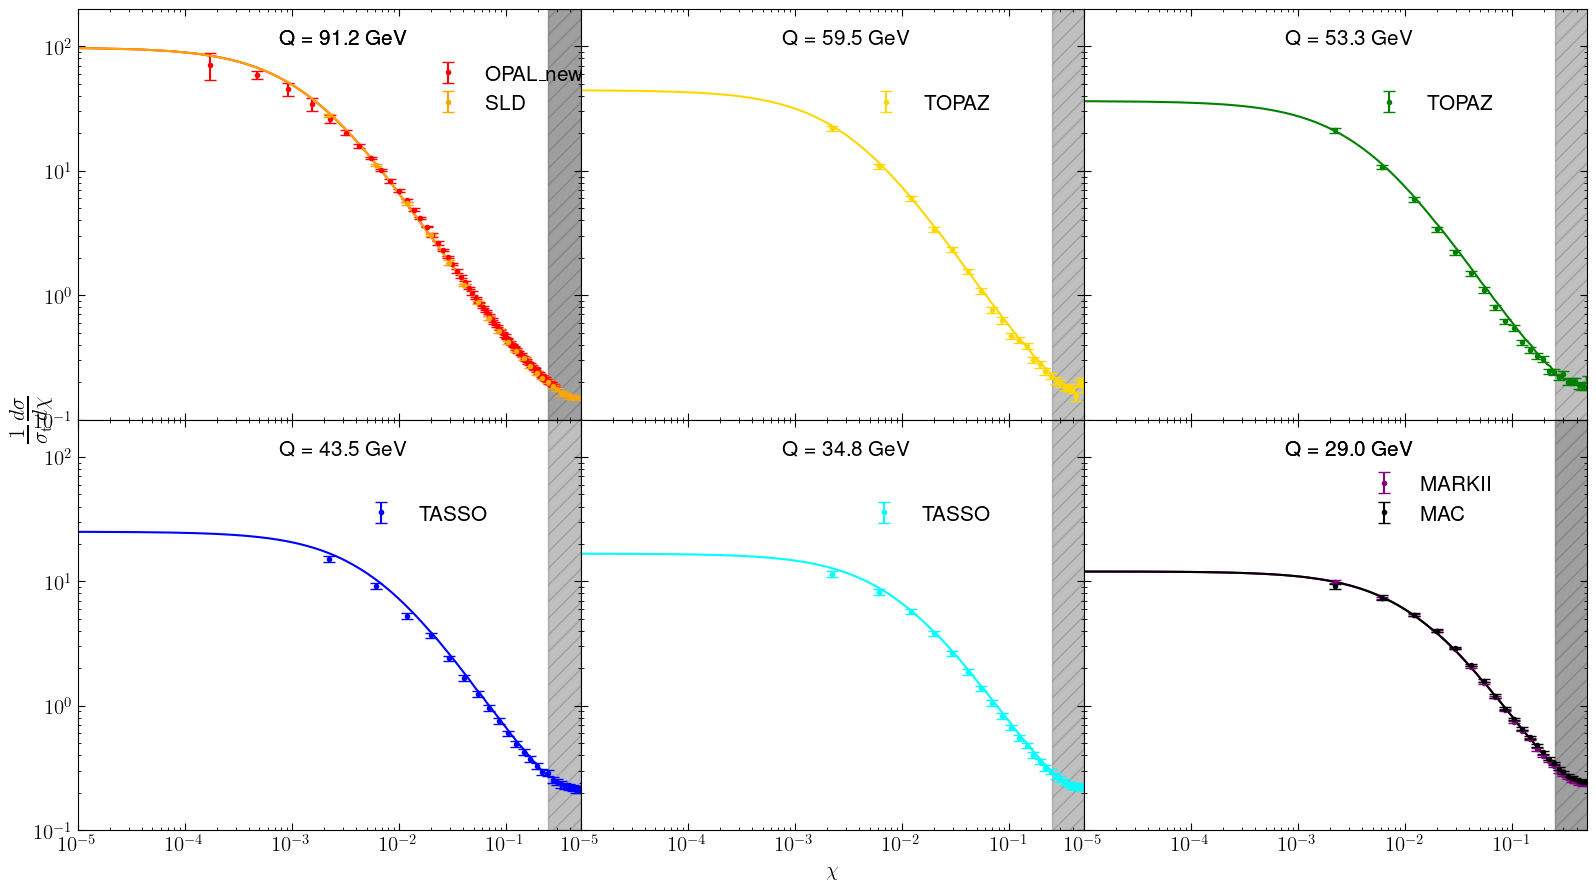

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0

predictionz={}

for Q in Q_set:
    for name in dataset_names:

        df[name]["z"] = (1-np.cos(df[name]["CHI"]*np.pi/180))/2
        df[name]["EECz"] = 2/np.sin(df[name]["CHI"]*np.pi/180)*df[name]["EEC"]
        df[name]["ERRORz"] = 2/np.sin(df[name]["CHI"]*np.pi/180)*df[name]["ERROR"]       
        predictionz[name] = 2/np.sin(xlist*np.pi/180)*(v[name])
        zlist = (1-np.cos(xlist*np.pi/180))/2

        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["z"], df[name]["EECz"], df[name]["ERRORz"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(zlist, predictionz[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            z_peak = sqrtz_cut**2
            ax_list[i].axvspan(z_peak, 1, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.85, 0.7))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.1, 200.0)
#plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0.00001,0.5)
plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [27]:
average_error={}

for name in dataset_names:
    l = len(χ[name])
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

KeyError: 'OPAL_new'

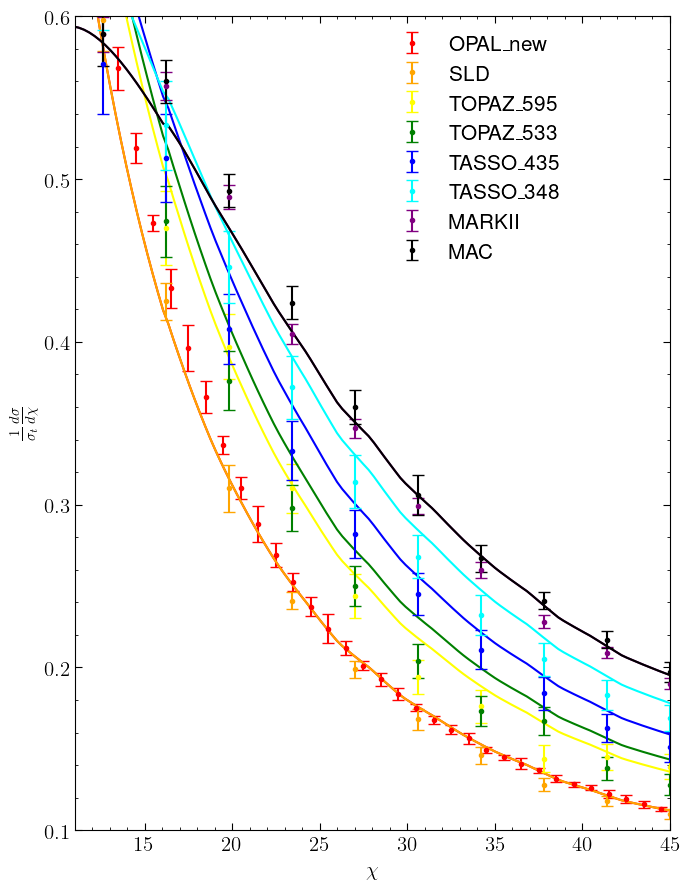

In [28]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black","yellow","orange"]
i=0
for name in dataset_names:
    ax1.errorbar(df_truncated[name]["CHI"], df_truncated[name]["EEC"], df_truncated[name]["ERROR"], fmt='o',label=str(name), color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist, v[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.5, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.1,0.6)
plt.xlim(11.0,45)

plt.tight_layout()  
plt.show()

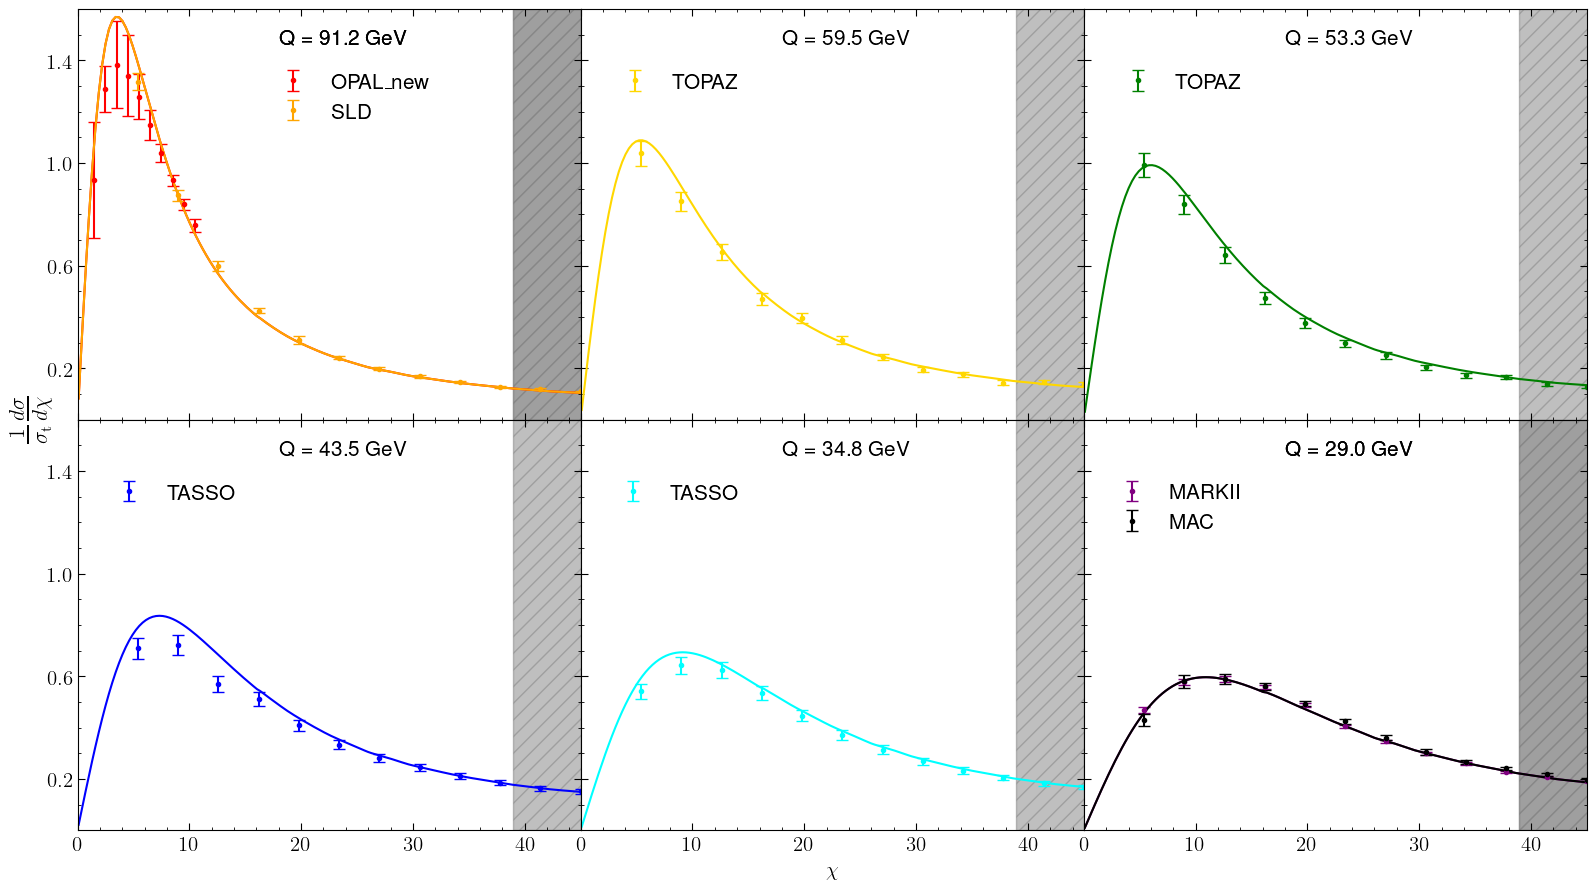

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            if name == "OPAL_new":
                ax_list[i].errorbar(df[name]["CHI"][0:10], df[name]["EEC"][0:10], df[name]["ERROR"][0:10], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
                ax_list[i].plot(xlist, v[name], color=color[j])
                ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
                #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
                χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
                #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
                ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
                j=j+1                
            else:
                ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
                ax_list[i].plot(xlist, v[name], color=color[j])
                ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
                #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
                χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
                #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
                ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
                j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,45)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [24]:
NLL = 2
χ_low = 0.1
χ_up = 70.0
kt_lower = 0
kt_upper = 100
sqrtz_cut = 1/2
optimal_params_list= [
    [0.118, 0.848, 2.78, 1.18],
    [0.118, 0.855, 2.77, 1.16],
    [0.118, 0.865, 2.73, 1.14],
    [0.118, 0.873, 2.7, 1.11],
    [0.118, 0.887, 2.62, 1.07]		
]

In [40]:
N_points = 100

xlist = np.linspace(χ_low, χ_up, N_points, endpoint=True)
length=len(xlist)

v_list=[]
for optimal_params in optimal_params_list:
    αs=optimal_params[0]
    params_noαs = optimal_params[1:]
    print(params_noαs)

    v={}
    non_singular = {}
    for name in dataset_names:
        
        Qlist = Q_list[name]*np.ones(N_points)

        parameters = params_noαs
        v[name] = Main.model(Qlist=Qlist, xlist=xlist, αs=αs, order=NLL, params=parameters)
    v_list.append(v)

[0.848, 2.78, 1.18]
[0.855, 2.77, 1.16]
[0.865, 2.73, 1.14]
[0.873, 2.7, 1.11]
[0.887, 2.62, 1.07]


NameError: name 'v_list' is not defined

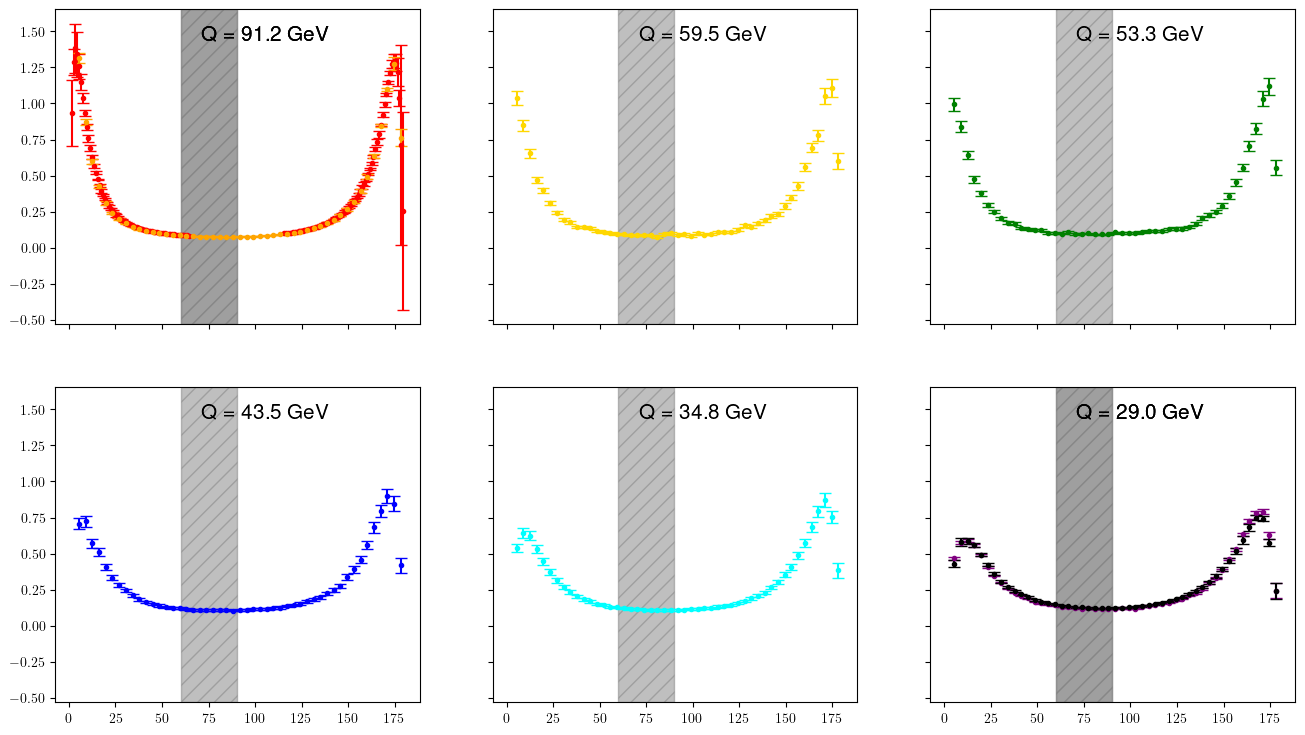

In [29]:
props = dict(boxstyle='round', facecolor='white', alpha=0)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
            χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
            #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
            ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

for n in range(5):
    i=0
    j=0
    for Q in Q_set:
        for name in dataset_names:
            if Q_list[name]==Q:
                ax_list[i].plot(xlist, v_list[n][name], color=color[j])
                j=j+1
        i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,65)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()